# Анализ и классификация данных пассажиров космического корабля Spaceship Titanic

## 0. Описание задачи

Данный проект посвящён анализу и решению задачи классификации на основе датасета **Spaceship Titanic** с платформы [Kaggle](https://www.kaggle.com/competitions/spaceship-titanic).  
Сюжет датасета вдохновлён историей «Титаника», но перенесён в космос: пассажиры космического лайнера **Spaceship Titanic** попали в аварию после столкновения с пространственно-временной аномалией.  

**Задача:**  
Необходимо предсказать, был ли пассажир транспортирован в другое измерение — то есть переменная **`Transported`** (целевая) принимает значения:  
- `True` — пассажир был перемещён;  
- `False` — пассажир не был перемещён.  

Таким образом, это задача **бинарной классификации**.  

**Цель проекта:**  
- провести предварительный анализ данных (EDA);  
- обработать пропущенные значения и категориальные признаки;  
- при необходимости нормализовать данные;  
- обучить и протестировать классификатор (например, метод k ближайших соседей);  
- подобрать оптимальные гиперпараметры и оценить качество модели;  
- сделать выводы о результатах работы модели и значимости признаков.  

### Описание признаков

**train.csv** — персональные данные примерно двух третей (~8700) пассажиров, которые будут использоваться в качестве обучающих данных:

| Признак       | Описание |
|---------------|----------|
| `PassengerId` | Уникальный идентификатор для каждого пассажира. Формат gggg_pp, где gggg — группа, pp — номер пассажира в группе. |
| `HomePlanet`  | Планета, с которой улетел пассажир (место проживания). |
| `CryoSleep`   | Решил ли пассажир погрузиться в анабиоз на время путешествия (True/False). |
| `Cabin`       | Номер каюты формата deck/num/side, side = P (левый борт) или S (правый борт). |
| `Destination` | Планета, на которую высадится пассажир. |
| `Age`         | Возраст пассажира. |
| `VIP`         | Оплачивал ли пассажир VIP-услуги (True/False). |
| `RoomService` | Сумма, потраченная на Room Service. |
| `FoodCourt`   | Сумма, потраченная в Food Court. |
| `ShoppingMall`| Сумма, потраченная в Shopping Mall. |
| `Spa`         | Сумма, потраченная на Spa. |
| `VRDeck`      | Сумма, потраченная на VR Deck. |
| `Name`        | Имя и фамилия пассажира. |
| `Transported` | Целевая переменная: был ли пассажир транспортирован (True/False). |

**test.csv** — персональные данные оставшихся одной трети (~4300) пассажиров, которые будут использоваться в качестве тестовых данных:  

| Признак       | Описание |
|---------------|----------|
| `PassengerId` | Идентификатор пассажира из test.csv |
| `Transported` | Предсказанное значение цели (True/False) |

### Типы признаков

- **Числовые (continuous):** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`  
- **Бинарные (boolean, категориальные с 2 значениями):** `CryoSleep`, `VIP`  
- **Категориальные текстовые:** `HomePlanet`, `Destination`, `Cabin`, `Name`  
- **Идентификатор:** `PassengerId` (не используется для обучения)  
- **Целевая переменная:** `Transported` (boolean)



## 1. Импорт библиотек и чтение данных

In [1]:
# Импорт библиотек
import numpy as np                                    # Работа с массивами
import pandas as pd                                   # Работа с таблицами (DataFrame)
import matplotlib.pyplot as plt                       # Визуализация данных
%matplotlib inline

import seaborn as sns                                 # Расширенная визуализация
import sklearn                                        # Машинное обучение и анализ данных
from sklearn.model_selection import train_test_split  # Разделение данных

# Чтение данных
train_df = pd.read_csv("../spaceship-titanic-dataset/train.csv")
test_df = pd.read_csv("../spaceship-titanic-dataset/test.csv")

# Размер структуры данных
print("Размер train.csv:", train_df.shape)
print("Размер test.csv:", test_df.shape)

# Вывод первых строк
train_df.head()

Размер train.csv: (8693, 14)
Размер test.csv: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Разбиение данных на обучающую и тестовую выборки

In [2]:
# Выделение признаков (X) и целевой переменной (y)
X = train_df.drop(columns=["Transported", "PassengerId"])
y = train_df["Transported"]

# Разделение на обучающую и тестовую выборки (например, 80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Проверка размеров выборок
print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (6954, 12)
Тестовая выборка: (1739, 12)


## 3. Визуализация данных и вычисление основных характеристик

In [3]:
# Общая информация по датасету
print("Типы признаков и непустых значений:")
X_train.info()

Типы признаков и непустых значений:
<class 'pandas.core.frame.DataFrame'>
Index: 6954 entries, 3600 to 7925
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    6785 non-null   object 
 1   CryoSleep     6786 non-null   object 
 2   Cabin         6793 non-null   object 
 3   Destination   6801 non-null   object 
 4   Age           6815 non-null   float64
 5   VIP           6796 non-null   object 
 6   RoomService   6809 non-null   float64
 7   FoodCourt     6800 non-null   float64
 8   ShoppingMall  6785 non-null   float64
 9   Spa           6804 non-null   float64
 10  VRDeck        6810 non-null   float64
 11  Name          6795 non-null   object 
dtypes: float64(6), object(6)
memory usage: 706.3+ KB


In [4]:
print("Статистики по числовым признакам:")
X_train.describe()

Статистики по числовым признакам:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,6815.000000,6809.000000,6800.000000,6785.000000,6804.000000,6810.000000
mean,28.683786,230.149508,452.611176,170.033604,308.868460,296.649927
std,14.497439,676.338160,1602.465410,548.753286,1142.118125,1108.581827
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,50.000000,65.500000,23.000000,55.000000,42.000000
max,79.000000,14327.000000,29813.000000,12253.000000,22408.000000,20336.000000


In [5]:
print("Статистики покатегоральным признакам:")
X_train.describe(include=['category', 'object', 'bool'])

Статистики покатегоральным признакам:


,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,6785,6786,6793,6801,6796,6795
unique,3,2,5435,3,2,6783
top,Earth,False,C/137/S,TRAPPIST-1e,False,Keitha Josey
freq,3673,4350,7,4694,6637,2


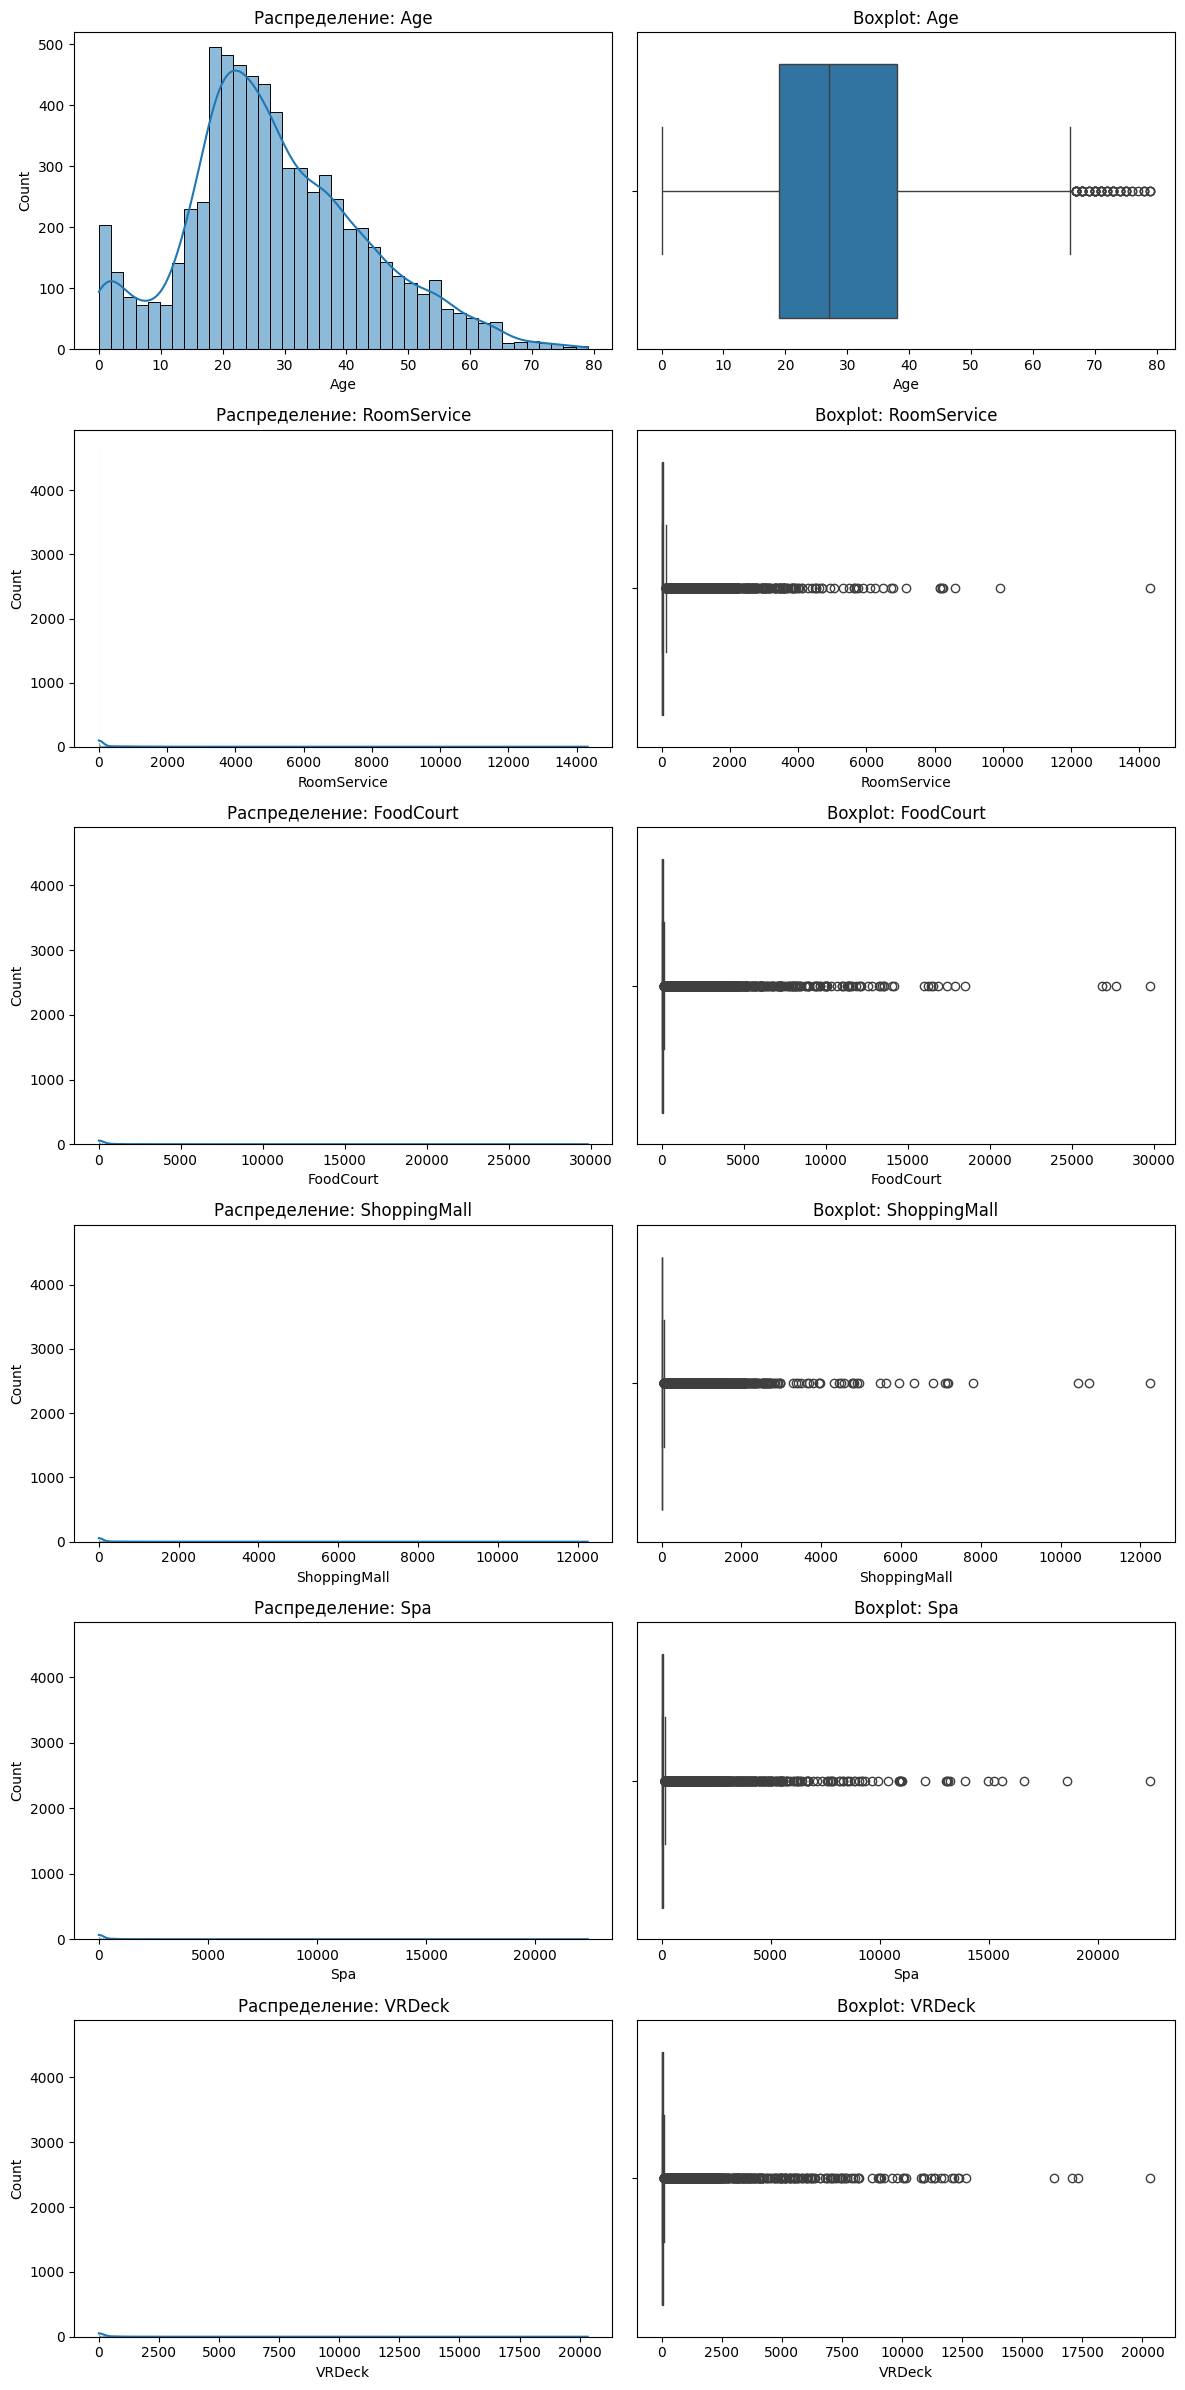

In [6]:
# Распределения числовых признаков (histogram + boxplot)
num_features = ["Age", "RoomService",
                "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(len(num_features), 2,
                         figsize=(12, 4 * len(num_features)))
for i, col in enumerate(num_features):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Распределение: {col}")

    sns.boxplot(data=X_train, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()


Распределение категориального признака `HomePlanet`:
HomePlanet
Earth     3673
Europa    1692
Mars      1420
NaN        169
Name: count, dtype: int64


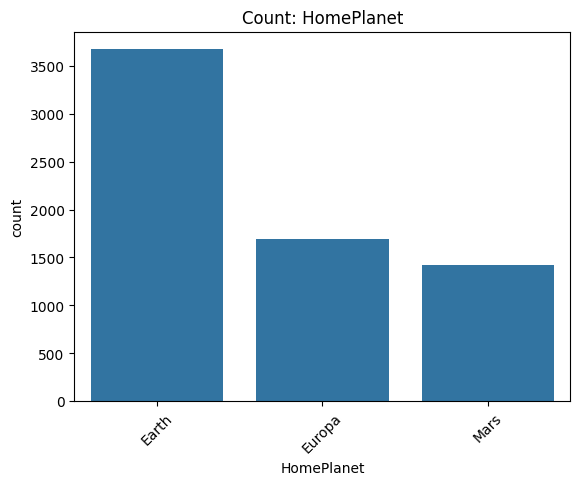


Распределение категориального признака `CryoSleep`:
CryoSleep
False    4350
True     2436
NaN       168
Name: count, dtype: int64


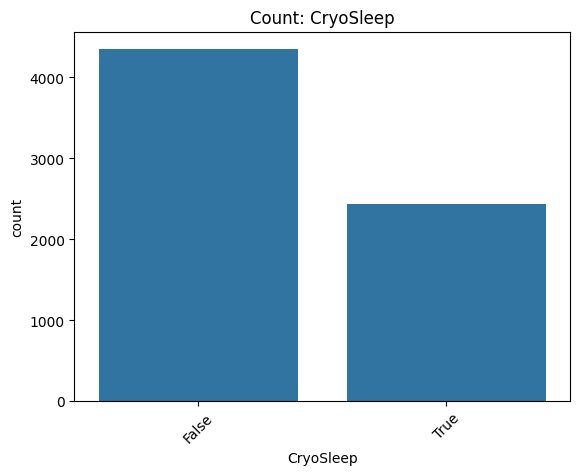


Распределение категориального признака `Cabin`:
Cabin
NaN         161
G/981/S       7
E/13/S        7
C/137/S       7
G/1368/P      7
G/765/S       6
G/292/S       6
B/201/P       6
C/319/S       6
A/67/P        6
Name: count, dtype: int64


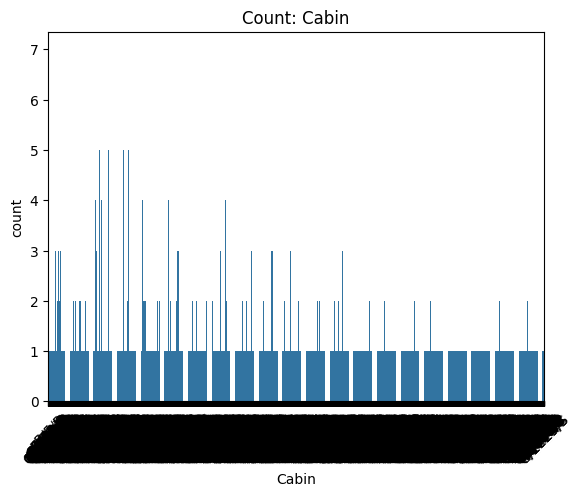


Распределение категориального признака `Destination`:
Destination
TRAPPIST-1e      4694
55 Cancri e      1452
PSO J318.5-22     655
NaN               153
Name: count, dtype: int64


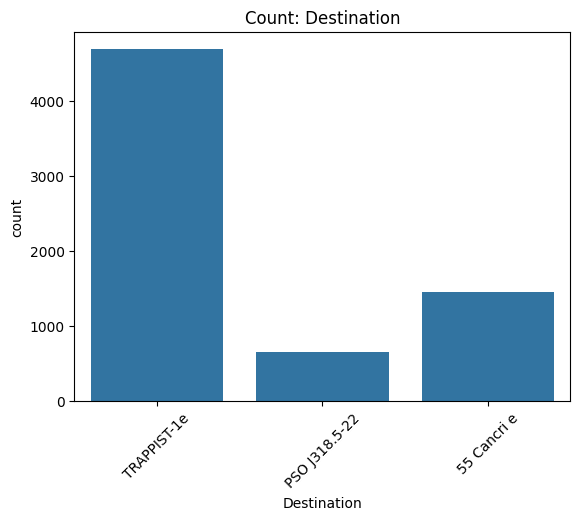


Распределение категориального признака `VIP`:
VIP
False    6637
True      159
NaN       158
Name: count, dtype: int64


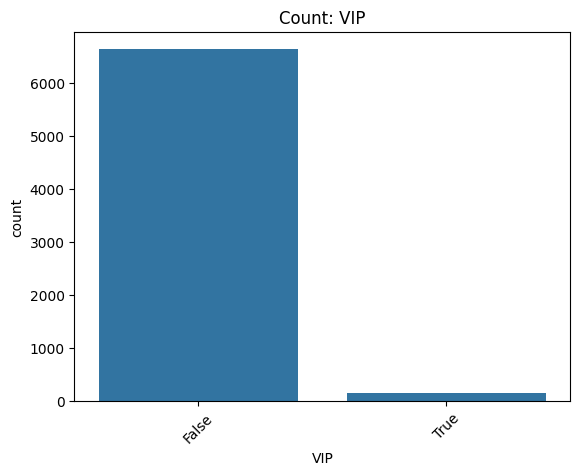


Распределение категориального признака `Name`:
Name
NaN                   159
Keitha Josey            2
Sharie Gallenry         2
Carry Contrevins        2
Gollux Reedall          2
Troya Schwardson        2
Juane Popelazquez       2
Glenna Valezaley        2
Sus Coolez              2
Elaney Webstephrey      2
Name: count, dtype: int64


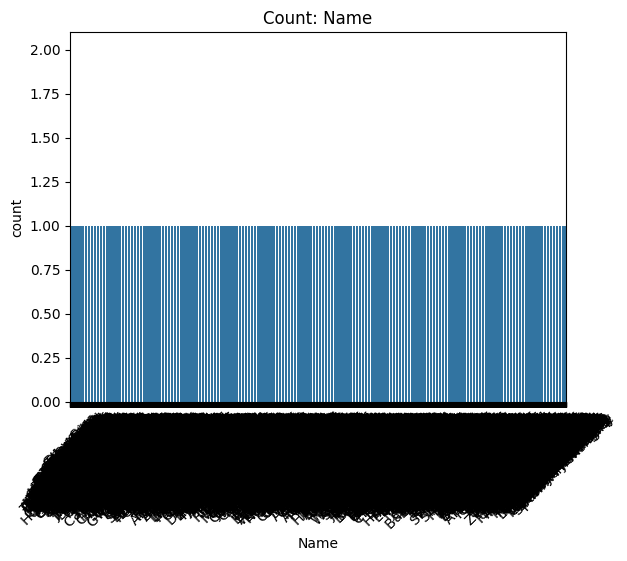

In [7]:
# Категориальные признаки — частоты
cat_features = ["HomePlanet", "CryoSleep",
                "Cabin", "Destination", "VIP", "Name"]
for col in cat_features:
    print(f"\nРаспределение категориального признака `{col}`:")
    print(X_train[col].value_counts(dropna=False).head(10))
    # Можно рисовать countplot для наиболее важный категорий:
    sns.countplot(data=X_train, x=col)
    plt.xticks(rotation=45)
    plt.title(f"Count: {col}")
    plt.show()

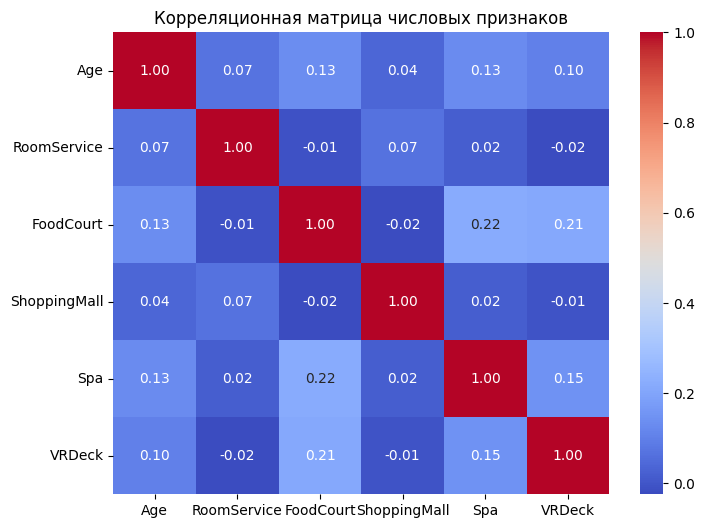

In [8]:
# Корреляционная матрица (для числовых признаков)
corr = X_train[num_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [9]:
# Между категориальными и целевой: средний таргет по категориям
for col in cat_features:
    df_tmp = pd.concat([X_train[col], y_train], axis=1)
    print(f"\nСредний `Transported` по группам признака `{col}`:")
    print(df_tmp.groupby(col)["Transported"].mean(
    ).sort_values(ascending=False).head(10))


Средний `Transported` по группам признака `HomePlanet`:
HomePlanet
Europa    0.661939
Mars      0.519718
Earth     0.424993
Name: Transported, dtype: float64

Средний `Transported` по группам признака `CryoSleep`:
CryoSleep
True     0.818555
False    0.327816
Name: Transported, dtype: float64

Средний `Transported` по группам признака `Cabin`:
Cabin
T/3/P      1.0
G/999/S    1.0
G/998/S    1.0
A/1/S      1.0
G/994/S    1.0
A/10/S     1.0
A/100/S    1.0
G/993/S    1.0
G/992/S    1.0
G/991/S    1.0
Name: Transported, dtype: float64

Средний `Transported` по группам признака `Destination`:
Destination
55 Cancri e      0.603306
PSO J318.5-22    0.503817
TRAPPIST-1e      0.472518
Name: Transported, dtype: float64

Средний `Transported` по группам признака `VIP`:
VIP
False    0.507308
True     0.371069
Name: Transported, dtype: float64

Средний `Transported` по группам признака `Name`:
Name
Zubeneb Flesping      1.0
Zosmas Mormonized     1.0
Zosmas Ineedeve       1.0
Zosmark Unaasor       1

## 4. Обработка пропущенных значений

In [10]:
# Проверим, есть ли пропуски в обучающих и тестовых данных
print("Количество пропущенных значений в X_train:")
display(X_train.isna().sum())

Количество пропущенных значений в X_train:


HomePlanet      169
CryoSleep       168
Cabin           161
Destination     153
Age             139
VIP             158
RoomService     145
FoodCourt       154
ShoppingMall    169
Spa             150
VRDeck          144
Name            159
dtype: int64

In [11]:
print("\nКоличество пропущенных значений в X_test:")
display(X_test.isna().sum())


Количество пропущенных значений в X_test:


HomePlanet      32
CryoSleep       49
Cabin           38
Destination     29
Age             40
VIP             45
RoomService     36
FoodCourt       29
ShoppingMall    39
Spa             33
VRDeck          44
Name            41
dtype: int64

In [12]:
# Также посмотрим, сколько строк содержит хотя бы один пропуск:
print("\nКоличество строк с пропущенными значениями в X_train:",
      X_train.isna().any(axis=1).sum())
print("Количество строк с пропущенными значениями в X_test:",
      X_test.isna().any(axis=1).sum())


Количество строк с пропущенными значениями в X_train: 1682
Количество строк с пропущенными значениями в X_test: 405


In [13]:
from sklearn.impute import SimpleImputer

# Выделяем числовые признаки
num_features = X_train.select_dtypes(include=[np.number]).columns
print("Числовые признаки:", list(num_features))

# Создаём и обучаем импутер
imp_num = SimpleImputer(missing_values=np.nan, strategy='median')
imp_num.fit(X_train[num_features])

# Применяем к train и test
X_train[num_features] = imp_num.transform(X_train[num_features])
X_test[num_features] = imp_num.transform(X_test[num_features])

Числовые признаки: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


In [14]:
# Выделяем категориальные признаки
cat_features = X_train.select_dtypes(include=['object', 'category']).columns
print("Категориальные признаки:", list(cat_features))

imp_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
imp_cat.fit(X_train[cat_features])

X_train[cat_features] = imp_cat.transform(X_train[cat_features])
X_test[cat_features] = imp_cat.transform(X_test[cat_features])

Категориальные признаки: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [15]:
print("После заполнения пропусков:")
display(X_train.isna().sum())
display(X_train.isna().sum())

После заполнения пропусков:


HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

## 5. Обработка категориальных признаков

In [16]:
# Посмотрим, какие признаки у нас категориальные
cat_features = X_train.select_dtypes(include=['object', 'category']).columns
print("Категориальные признаки:", list(cat_features))

Категориальные признаки: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [17]:
for col in cat_features:
    print(
        f"{col}: {X_train[col].nunique()} уникальных значений — {X_train[col].unique()[:5]}")

HomePlanet: 3 уникальных значений — ['Earth' 'Europa' 'Mars']
CryoSleep: 2 уникальных значений — [False True]
Cabin: 5435 уникальных значений — ['G/630/S' 'G/201/S' 'G/1483/S' 'D/164/S' 'G/818/P']
Destination: 3 уникальных значений — ['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
VIP: 2 уникальных значений — [False True]
Name: 6783 уникальных значений — ['Harrie Braymon' 'Apix Wala' 'Camily Howence' 'Pleion Sperap'
 'Alicey Wolferguson']


In [18]:
binary_cols = [col for col in cat_features if X_train[col].nunique() == 2]
nonbinary_cols = [col for col in cat_features if X_train[col].nunique() > 2]

print("Бинарные признаки:", binary_cols)
print("Небинарные признаки:", nonbinary_cols)

Бинарные признаки: ['CryoSleep', 'VIP']
Небинарные признаки: ['HomePlanet', 'Cabin', 'Destination', 'Name']


In [19]:
# Преобразуем бинарные признаки в числовой формат
for col in binary_cols:
    X_train[col] = X_train[col].map({False: 0, True: 1})
    X_test[col] = X_test[col].map({False: 0, True: 1})

In [20]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Приводим все нечисловые категориальные столбцы к строкам
X_train[nonbinary_cols] = X_train[nonbinary_cols].astype(str)
X_test[nonbinary_cols] = X_test[nonbinary_cols].astype(str)

# Создаём и обучаем энкодер
enc = OneHotEncoder(drop='if_binary', sparse_output=False,
                    handle_unknown='ignore')
enc.fit(X_train[nonbinary_cols])

# Преобразуем train и test
train_dummies = pd.DataFrame(
    enc.transform(X_train[nonbinary_cols]),
    columns=enc.get_feature_names_out(nonbinary_cols),
    index=X_train.index
)
test_dummies = pd.DataFrame(
    enc.transform(X_test[nonbinary_cols]),
    columns=enc.get_feature_names_out(nonbinary_cols),
    index=X_test.index
)

# Добавляем dummy-столбцы и удаляем исходные
X_train = pd.concat(
    [X_train.drop(nonbinary_cols, axis=1), train_dummies], axis=1)
X_test = pd.concat([X_test.drop(nonbinary_cols, axis=1), test_dummies], axis=1)

print("Категориальные признаки успешно преобразованы.")
display(X_train.head())

c:\Users\ilush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Категориальные признаки успешно преобразованы.


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,...,Name_Zinopus Fuelddid,Name_Zinopus Spandisket,Name_Zinor Axlentindy,Name_Zinor Proorbeng,Name_Zosmark Trattle,Name_Zosmark Unaasor,Name_Zosmas Ineedeve,Name_Zosmas Mormonized,Name_Zubeneb Flesping,Name_Zubeneb Pasharne
3600,0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1262,1,17.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8612,0,35.0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5075,1,26.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4758,0,13.0,0,0.0,0.0,60.0,1.0,5147.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Нормализация

In [21]:
from sklearn.preprocessing import StandardScaler

# Отбираем числовые (количественные) признаки
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Создаём и обучаем стандартизатор
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

# Преобразуем train и test выборки
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Проверим результат масштабирования
X_train[num_cols].describe()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,...,Name_Zinopus Fuelddid,Name_Zinopus Spandisket,Name_Zinor Axlentindy,Name_Zinor Proorbeng,Name_Zosmark Trattle,Name_Zosmark Unaasor,Name_Zosmas Ineedeve,Name_Zosmas Mormonized,Name_Zubeneb Flesping,Name_Zubeneb Pasharne
count,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,...,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6.954000e+03,6954.000000,6954.000000,6.954000e+03,6.954000e+03
mean,-4.904523e-17,-2.145729e-17,1.430486e-17,1.992462e-17,-2.043551e-17,-3.371859e-17,1.226131e-17,1.430486e-17,7.765494e-17,6.130653e-18,...,2.043551e-18,4.087102e-18,3.065327e-18,1.021776e-18,5.108878e-18,3.065327e-18,0.000000,0.000000,1.226131e-17,5.108878e-18
std,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,...,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072e+00,1.000072,1.000072,1.000072e+00,1.000072e+00
min,-7.342865e-01,-1.996149e+00,-1.529691e-01,-3.363401e-01,-2.790759e-01,-3.057321e-01,-2.673111e-01,-2.646323e-01,-1.111115e+00,-5.670544e-01,...,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-0.011993,-0.011993,-1.199261e-02,-1.199261e-02
25%,-7.342865e-01,-6.723564e-01,-1.529691e-01,-3.363401e-01,-2.790759e-01,-3.057321e-01,-2.673111e-01,-2.646323e-01,-1.111115e+00,-5.670544e-01,...,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-0.011993,-0.011993,-1.199261e-02,-1.199261e-02
50%,-7.342865e-01,-1.149700e-01,-1.529691e-01,-3.363401e-01,-2.790759e-01,-3.057321e-01,-2.673111e-01,-2.646323e-01,8.999971e-01,-5.670544e-01,...,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-0.011993,-0.011993,-1.199261e-02,-1.199261e-02
75%,1.361866e+00,5.817631e-01,-1.529691e-01,-2.721618e-01,-2.445530e-01,-2.688750e-01,-2.248535e-01,-2.311555e-01,8.999971e-01,-5.670544e-01,...,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-1.199261e-02,-0.011993,-0.011993,-1.199261e-02,-1.199261e-02
max,1.361866e+00,3.508042e+00,6.537266e+00,2.104698e+01,1.851965e+01,2.227477e+01,1.955329e+01,1.826009e+01,8.999971e-01,1.763499e+00,...,8.338465e+01,8.338465e+01,8.338465e+01,8.338465e+01,8.338465e+01,8.338465e+01,83.384651,83.384651,8.338465e+01,8.338465e+01


## 7. Запуск классификатора ближайших соседей

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Создаём и обучаем классификатор
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

# Предсказания для тестовой выборки
y_test_predict = knn.predict(X_test)

## 8. Вычисление ошибки на обучающей и тестовой выборках, выбор оптимального значения гиперпараметра

Ошибки на обучающей и тестовой выборках

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Ошибки на train и test выборках
err_train = np.mean(y_train != knn.predict(X_train))
err_test = np.mean(y_test != y_test_predict)

print(f"Ошибка на обучающей выборке: {err_train:.4f}")
print(f"Ошибка на тестовой выборке: {err_test:.4f}")

# Альтернативный способ через встроенный score()
print("\nАльтернативный способ:")
print(f"Точность на обучающей выборке: {knn.score(X_train, y_train):.4f}")
print(f"Точность на тестовой выборке: {knn.score(X_test, y_test):.4f}")
print(f"Ошибка на обучающей выборке: {1 - knn.score(X_train, y_train):.4f}")
print(f"Ошибка на тестовой выборке: {1 - knn.score(X_test, y_test):.4f}")

Ошибка на обучающей выборке: 0.5036
Ошибка на тестовой выборке: 0.5037

Альтернативный способ:
Точность на обучающей выборке: 0.4964
Точность на тестовой выборке: 0.4963
Ошибка на обучающей выборке: 0.5036
Ошибка на тестовой выборке: 0.5037


Матрицы рассогласования (confusion matrix)

Матрица ошибок (confusion matrix):
[[863   0]
 [876   0]]


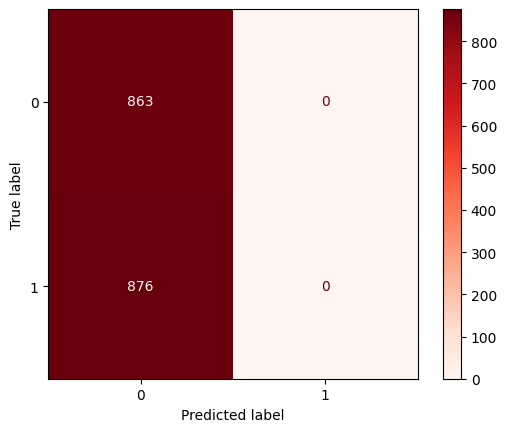

In [ ]:
cm = confusion_matrix(y_test, y_test_predict)

ConfusionMatrixDisplay(cm).plot(cmap='Reds')

**Комментарий:**

- Значения на **главной диагонали** матрицы ошибок показывают количество правильных классификаций.
- Чем больше эти значения по сравнению с внедиагональными, тем лучше работает модель.
- Ошибка на тестовой выборке показывает, насколько хорошо модель обобщает данные, не переобучаясь.

Если ошибка на обучающей выборке значительно меньше, чем на тестовой, — модель **переобучена**.  
Если обе ошибки велики — модель **недообучена** (слишком малое k или неудачная нормализация).


Подбор оптимального числа соседей (гиперпараметр k)

In [52]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Зададим диапазон k
k_values = [1, 3, 5, 7, 10, 15, 20, 25, 35, 45, 55]

# Настраиваем GridSearchCV
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid={'n_neighbors': k_values}, cv=5)
grid.fit(X_train, y_train)

# Лучшие результаты
best_k = grid.best_estimator_.n_neighbors
best_cv_err = 1 - grid.best_score_

print(f"Лучшее значение k: {best_k}")
print(f"Минимальная кросс-валидационная ошибка: {best_cv_err:.4f}")

Лучшее значение k: 55
Минимальная кросс-валидационная ошибка: 0.3789


Визуализация зависимости ошибки от числа соседей

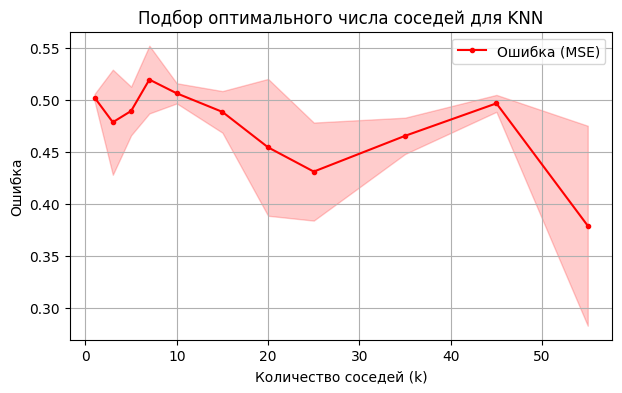

In [53]:
mean_err = 1 - grid.cv_results_['mean_test_score']
std_err = grid.cv_results_['std_test_score']

plt.figure(figsize=(7, 4))
plt.plot(k_values, mean_err, 'r.-', label='Ошибка (MSE)')
plt.fill_between(k_values, mean_err - std_err, mean_err +
                 std_err, alpha=0.2, color='red')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Ошибка')
plt.title('Подбор оптимального числа соседей для KNN')
plt.grid(True)
plt.legend()
plt.show()

Повторное обучение с оптимальным k

In [54]:
# Обучаем KNN с найденным оптимальным k
knn_opt = KNeighborsClassifier(n_neighbors=best_k)
knn_opt.fit(X_train, y_train)

# Ошибки на train и test
err_train_opt = np.mean(y_train != knn_opt.predict(X_train))
err_test_opt = np.mean(y_test != knn_opt.predict(X_test))

print(
    f"Ошибка на обучающей выборке (оптимальное k={best_k}): {err_train_opt:.4f}")
print(
    f"Ошибка на тестовой выборке (оптимальное k={best_k}): {err_test_opt:.4f}")

Ошибка на обучающей выборке (оптимальное k=55): 0.0417
Ошибка на тестовой выборке (оптимальное k=55): 0.4595


## 9. Запуск других классификаторов и сравнение результатов

In [55]:
import pandas as pd
from sklearn import ensemble
from sklearn.svm import SVC

# Словарь для хранения моделей и их ошибок
results = {}

- SVC

In [ ]:
svc = SVC(gamma='auto')
svc.fit(X_train, y_train)

svc_err_train = np.mean(y_train != svc.predict(X_train))
svc_err_test = np.mean(y_test != svc.predict(X_test))

results['SVC'] = (svc_err_train, svc_err_test)
print(svc_err_train, svc_err_test)

- Random Forest

In [ ]:
rf = ensemble.RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(X_train, y_train)

rf_err_train = np.mean(y_train != rf.predict(X_train))
rf_err_test = np.mean(y_test != rf.predict(X_test))

results['RandomForest'] = (rf_err_train, rf_err_test)
print(rf_err_train, rf_err_test)

- Extremely Randomized Trees (ExtraTrees)

In [ ]:
ert = ensemble.ExtraTreesClassifier(n_estimators=100, random_state=42)
ert.fit(X_train, y_train)

ert_err_train = np.mean(y_train != ert.predict(X_train))
ert_err_test = np.mean(y_test != ert.predict(X_test))

results['ExtraTrees'] = (ert_err_train, ert_err_test)
print(ert_err_train, ert_err_test)

- AdaBoost

In [ ]:
ada = ensemble.AdaBoostClassifier(n_estimators=1000, random_state=42)
ada.fit(X_train, y_train)

ada_err_train = np.mean(y_train != ada.predict(X_train))
ada_err_test = np.mean(y_test != ada.predict(X_test))

results['AdaBoost'] = (ada_err_train, ada_err_test)
print(ada_err_train, ada_err_test)

- Gradient Boosting (GBT)

In [ ]:
gbt = ensemble.GradientBoostingClassifier(n_estimators=1000, random_state=42)
gbt.fit(X_train, y_train)

gbt_err_train = np.mean(y_train != gbt.predict(X_train))
gbt_err_test = np.mean(y_test != gbt.predict(X_test))

results['GradientBoosting'] = (gbt_err_train, gbt_err_test)
print(gbt_err_train, gbt_err_test)

Сравнение результатов

In [ ]:
df_results = pd.DataFrame(results, index=['Train Error', 'Test Error']).T
df_results['Train Accuracy'] = 1 - df_results['Train Error']
df_results['Test Accuracy'] = 1 - df_results['Test Error']
df_results = df_results.drop(columns=['Train Error', 'Test Error'])
df_results = df_results.sort_values(by='Test Accuracy', ascending=False)

print("Сравнение классификаторов по точности:")
display(df_results)

## 10. Борьба с несбалансированностью классов

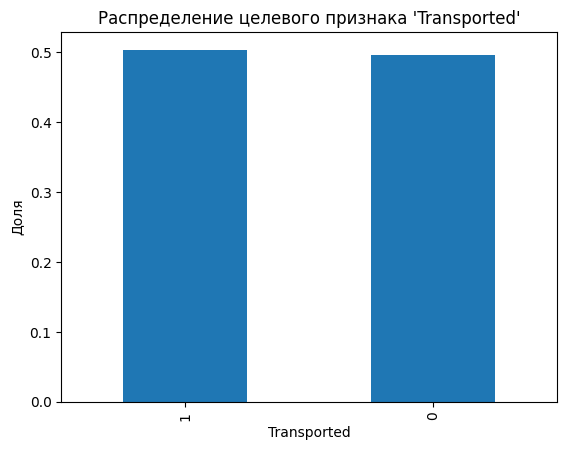

Соотношение классов (доля каждого класса):
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Проверка баланса классов
y_train.value_counts(normalize=True).plot(kind='bar')
plt.title("Распределение целевого признака 'Transported'")
plt.ylabel("Доля")
plt.show()

print("Соотношение классов (доля каждого класса):")
print(y_train.value_counts(normalize=True))

## 11. Исключение коррелированных переменных

Зачем это нужно:

1. Сильная корреляция между признаками (multicollinearity) может:

    - Нарушать работу линейных моделей (например, LogisticRegression), приводя к нестабильным коэффициентам.
    - Увеличивать шум и переобучение в некоторых алгоритмах.

2. Исключение одного из сильно коррелированных признаков помогает:

    - Сократить размерность данных.
    - Сделать модель более устойчивой.
    - Снизить вычислительные затраты.

In [ ]:
import pandas as pd
import numpy as np

# Создадим DataFrame из закодированных признаков (после OneHotEncoder)
X_train_df = pd.DataFrame(X_train)

# Вычисляем корреляционную матрицу
corr_matrix = X_train_df.corr().abs()

# Создаем маску для верхнего треугольника (не повторяем пары)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Определяем признаки с корреляцией выше порога (например, 0.9)
threshold = 0.9
to_drop = [column for column in upper_tri.columns if any(
    upper_tri[column] > threshold)]

print(
    f"Признаки, которые можно исключить из-за высокой корреляции (>{threshold}):")
print(to_drop)

# Удаляем сильно коррелированные признаки
X_train_reduced = X_train_df.drop(columns=to_drop)
X_test_reduced = pd.DataFrame(X_test).drop(columns=to_drop)

print(f"Размер X_train до удаления: {X_train_df.shape}")
print(f"Размер X_train после удаления: {X_train_reduced.shape}")

## 12. Общие выводы